
Seasonal Naive - Test Set Evaluation:
RMSE: 4.91
MAE: 2.70
R² Score: 0.81


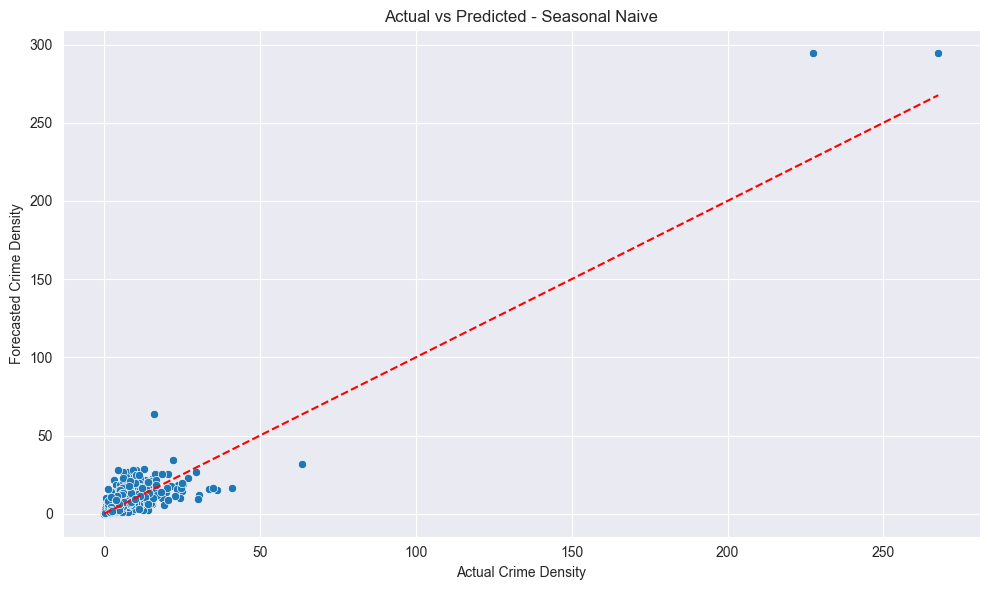

In [5]:
# -----------------------------
# Imports
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import os
# -----------------------------
# Load and Clean Data
# -----------------------------
# Get the absolute path to the file
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)  # Go up one directory
file_path = os.path.join(parent_dir, "output_csv_files", "ward_temporal_analysis.csv")

# Load and prepare data
df = pd.read_csv(file_path, parse_dates=['Month'])
df['Month'] = pd.to_datetime(df['Month'], errors='coerce')
df = df.dropna()

# Extract year and numeric month
df['Year'] = df['Month'].dt.year
df['Month_Num'] = df['Month'].dt.month

# Encode categorical Ward ID
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Ward ID'] = le.fit_transform(df['Ward ID'])

# -----------------------------
# Train-Test Split
# -----------------------------
df_train = df[df['Year'] <= 2024]
df_test = df[df['Year'] > 2024]

# -----------------------------
# Seasonal Naive Forecast
# -----------------------------
# Use 2024 values to forecast 2025 based on Ward ID + Month_Num
lookup = df_train[df_train['Year'] == 2024][['Ward ID', 'Month_Num', 'Monthly_Crime_Density']]
lookup = lookup.rename(columns={'Monthly_Crime_Density': 'Forecast'})

# Merge forecast with actual test data for 2025
df_test = df_test.merge(lookup, on=['Ward ID', 'Month_Num'], how='left')

# Drop missing forecasts (if any)
df_test = df_test.dropna(subset=['Forecast'])

# -----------------------------
# Evaluation
# -----------------------------
y_true = df_test['Monthly_Crime_Density']
y_pred = df_test['Forecast']

def evaluate_model(y_true, y_pred, dataset_name=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{dataset_name} Evaluation:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R² Score: {r2:.2f}")
    return rmse, mae, r2

evaluate_model(y_true, y_pred, "Seasonal Naive - Test Set")

# -----------------------------
# Visualization
# -----------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_true, y=y_pred)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], color='red', linestyle='--')
plt.title('Actual vs Predicted - Seasonal Naive')
plt.xlabel('Actual Crime Density')
plt.ylabel('Forecasted Crime Density')
plt.grid(True)
plt.tight_layout()
plt.show()


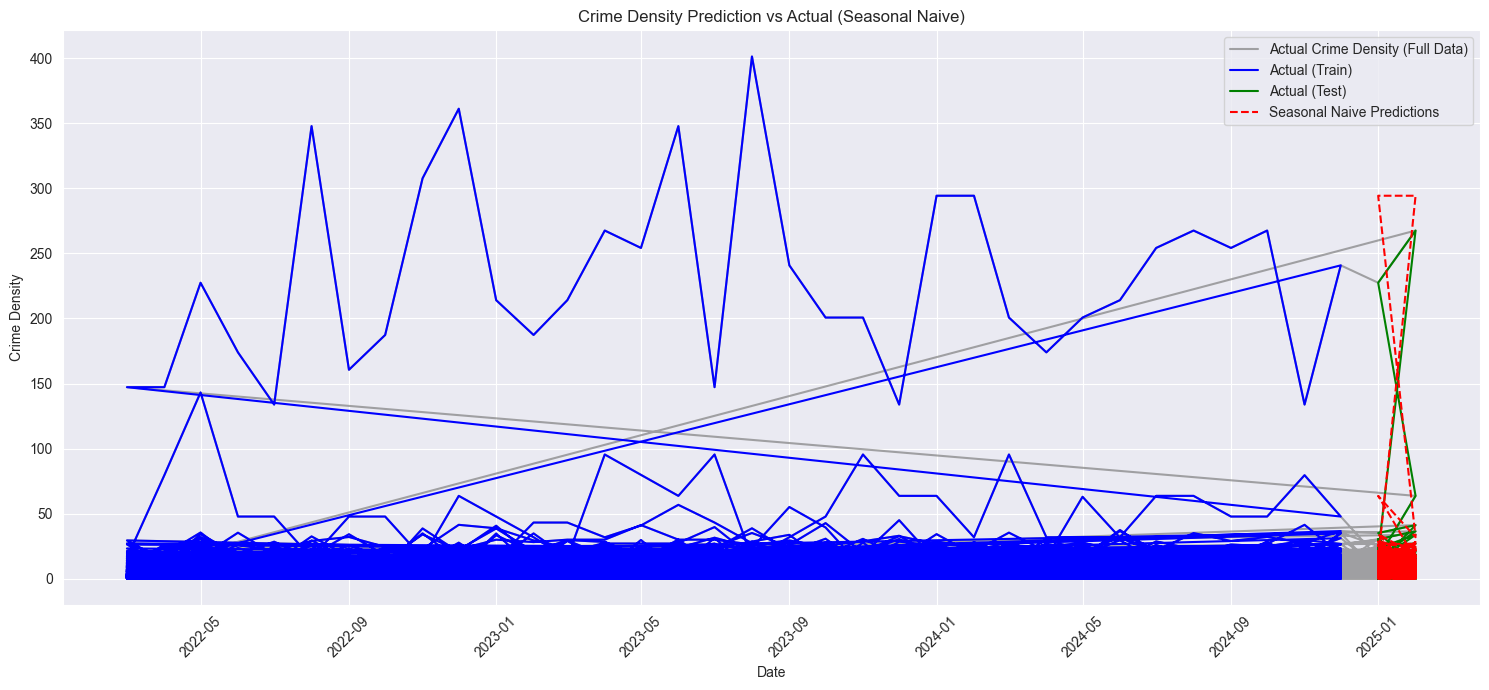

In [6]:
# Plot
plt.figure(figsize=(15, 7))

# Plot full actual data
plt.plot(df['Month'], df['Monthly_Crime_Density'], 
         label='Actual Crime Density (Full Data)', color='gray', alpha=0.7)

# Plot training data
plt.plot(df_train['Month'], df_train['Monthly_Crime_Density'], 
         label='Actual (Train)', color='blue')

# Plot test data
plt.plot(df_test['Month'], df_test['Monthly_Crime_Density'], 
         label='Actual (Test)', color='green')

# Plot predictions
plt.plot(df_test['Month'], df_test['Forecast'], 
         label='Seasonal Naive Predictions', color='red', linestyle='--')

plt.title('Crime Density Prediction vs Actual (Seasonal Naive)')
plt.xlabel('Date')
plt.ylabel('Crime Density')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()